In [1]:
import torch
import torchvision
import torch.utils.data
import torchvision.transforms.v2

transforms = torchvision.transforms.v2.Compose(
    [
        torchvision.transforms.v2.Resize(224),
        torchvision.transforms.v2.Grayscale(num_output_channels=3),
        torchvision.transforms.v2.ToImage(),
        torchvision.transforms.v2.ToDtype(torch.float32, scale=True),
        torchvision.transforms.v2.Normalize((0.1307,), (0.3081,)),
    ]
)
train_ds = torchvision.datasets.MNIST("mnist", train=True, download=True, transform=transforms)
test_ds = torchvision.datasets.MNIST("mnist", train=False, download=True, transform=transforms)
classes = train_ds.class_to_idx

K_NEIGHBORS = 4
MAX_DIMENSION = 1

In [2]:
import zigzag.nn
import zigzag.utils

dumper = zigzag.utils.UniversalDumper("mnist/resnet_small")

model = torchvision.models.resnet18(
    num_classes=1000, weights=torchvision.models.ResNet18_Weights.DEFAULT
)
model.fc = torch.nn.Identity()

train_embeddings = dumper.execute(
    zigzag.nn.precompute_embeddings,
    "train_embeddings",
    model,
    torch.utils.data.DataLoader(train_ds, batch_size=128, shuffle=False, num_workers=3)
)
test_embeddings = dumper.execute(
    zigzag.nn.precompute_embeddings,
    "test_embeddings",
    model,
    torch.utils.data.DataLoader(test_ds, batch_size=128, shuffle=False, num_workers=3)
)

Got the result from mnist/resnet_small/train_embeddings.pt
Got the result from mnist/resnet_small/test_embeddings.pt


In [3]:
train_emb_ds = torch.utils.data.TensorDataset(train_embeddings, train_ds.targets)
test_emb_ds = torch.utils.data.TensorDataset(test_embeddings, test_ds.targets)

head = torch.nn.Sequential(torch.nn.LazyLinear(len(classes)), torch.nn.Softmax(dim=1))
train_history = dumper.execute(
    zigzag.nn.train,
    "train_history",
    head,
    torch.utils.data.DataLoader(train_emb_ds, batch_size=128, shuffle=True, num_workers=3),
    torch.utils.data.DataLoader(test_emb_ds, batch_size=128, shuffle=False, num_workers=3),
)

Got the result from mnist/resnet_small/train_history.csv


/usr/local/lib/python3.12/site-packages/torch/nn/modules/lazy.py:181: UserWarning: Lazy modules are a new feature under heavy development so changes to the API or functionality can happen at any moment.
  warnings.warn('Lazy modules are a new feature under heavy development '


In [4]:
train_img_ds = torch.utils.data.Subset(train_ds, indices=range(1000))

hidden_states = dumper.execute(
    zigzag.nn.collect_hidden_states,
    "hidden_states",
    model,
    torch.utils.data.DataLoader(train_img_ds, batch_size=128, shuffle=False, num_workers=3)
)
num_layers = len(hidden_states)

Got the result from mnist/resnet_small/hidden_states
Got the result from mnist/resnet_small/hidden_states/0.pt
Got the result from mnist/resnet_small/hidden_states/1.pt
Got the result from mnist/resnet_small/hidden_states/2.pt
Got the result from mnist/resnet_small/hidden_states/3.pt
Got the result from mnist/resnet_small/hidden_states/4.pt
Got the result from mnist/resnet_small/hidden_states/5.pt
Got the result from mnist/resnet_small/hidden_states/6.pt
Got the result from mnist/resnet_small/hidden_states/7.pt
Got the result from mnist/resnet_small/hidden_states/8.pt


In [7]:
import zigzag.topology

persistence_diagrams = dumper.execute(
    zigzag.topology.make_cubical_persistence,
    "persistence_diagrams",
    hidden_states
)
knn_graphs = dumper.execute(
    zigzag.topology.make_knn_graphs_pds,
    "knn_graphs",
    persistence_diagrams,
    k_neighbors=K_NEIGHBORS,
    metric='landscape'
)
diagrams = dumper.execute(
    zigzag.topology.compute_zigzag_barcodes,
    "diagrams",
    knn_graphs,
    dimension=MAX_DIMENSION
)

Got the result from mnist/resnet_small/persistence_diagrams
Got the result from mnist/resnet_small/persistence_diagrams/0.npy
Got the result from mnist/resnet_small/persistence_diagrams/1.npy
Got the result from mnist/resnet_small/persistence_diagrams/2.npy
Got the result from mnist/resnet_small/persistence_diagrams/3.npy
Got the result from mnist/resnet_small/persistence_diagrams/4.npy
Got the result from mnist/resnet_small/persistence_diagrams/5.npy
Got the result from mnist/resnet_small/persistence_diagrams/6.npy
Got the result from mnist/resnet_small/persistence_diagrams/7.npy
Got the result from mnist/resnet_small/persistence_diagrams/8.npy


KNN graphs:  22%|██▏       | 2/9 [00:00<00:03,  2.01it/s]/usr/local/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
KNN graphs: 100%|██████████| 9/9 [00:06<00:00,  1.32it/s]


Saving the result to mnist/resnet_small/knn_graphs
Saving the result to mnist/resnet_small/knn_graphs/0.npz
Saving the result to mnist/resnet_small/knn_graphs/1.npz
Saving the result to mnist/resnet_small/knn_graphs/2.npz
Saving the result to mnist/resnet_small/knn_graphs/3.npz
Saving the result to mnist/resnet_small/knn_graphs/4.npz
Saving the result to mnist/resnet_small/knn_graphs/5.npz
Saving the result to mnist/resnet_small/knn_graphs/6.npz
Saving the result to mnist/resnet_small/knn_graphs/7.npz
Saving the result to mnist/resnet_small/knn_graphs/8.npz


Generate simplex tree: 100%|██████████| 9/9 [00:00<00:00, 69.98it/s]


[======================================================================] 100%
Saving the result to mnist/resnet_small/diagrams
Saving the result to mnist/resnet_small/diagrams/0.npy
Saving the result to mnist/resnet_small/diagrams/1.npy


/Users/abramov-alex/Desktop/HSE/CourseProject-Mag-1/zigzag/topology/plotting.py:45: RuntimeWarning: divide by zero encountered in log10
  im = ax.imshow(numpy.log10(pis_pers), cmap=CMAP, origin="lower")


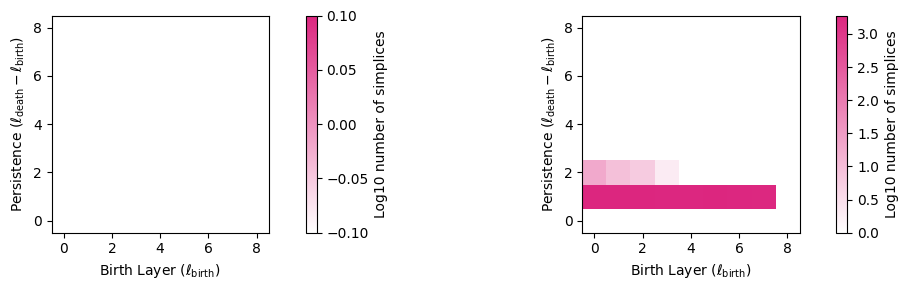

In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize = (13, 3))
for diagram, ax in zip(diagrams, axes.flat):
    zigzag.topology.plot_persistence_image(diagram, num_layers, ax=ax)
fig.savefig(f"{dumper.directory_}/persistence_image.png")
fig.savefig(f"{dumper.directory_}/persistence_image.svg")

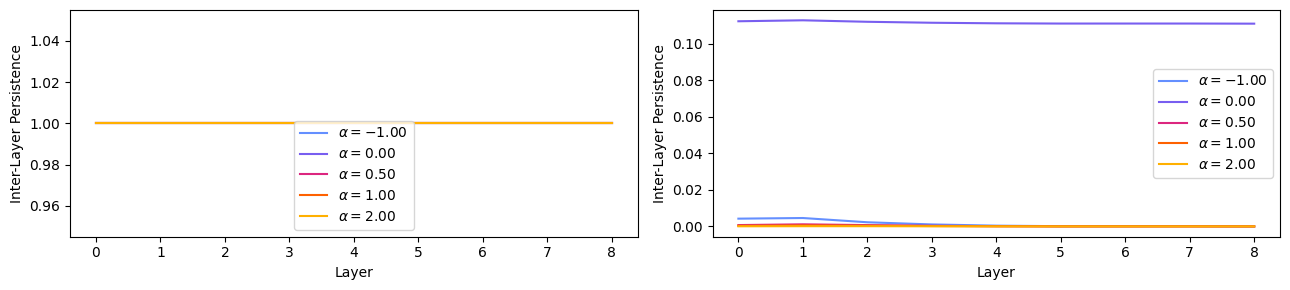

In [9]:
fig, axes = plt.subplots(1, 2, figsize = (13, 3))
for diagram, ax in zip(diagrams, axes.flat):
    zigzag.topology.plot_weighted_inter_layer_persistence(diagram, num_layers, ax=ax)
fig.savefig(f"{dumper.directory_}/inter_layer_persistence.png")
fig.savefig(f"{dumper.directory_}/inter_layer_persistence.svg")

/Users/abramov-alex/Desktop/HSE/CourseProject-Mag-1/zigzag/topology/metrics.py:80: RuntimeWarning: invalid value encountered in divide
  return result / numpy.sum(result)


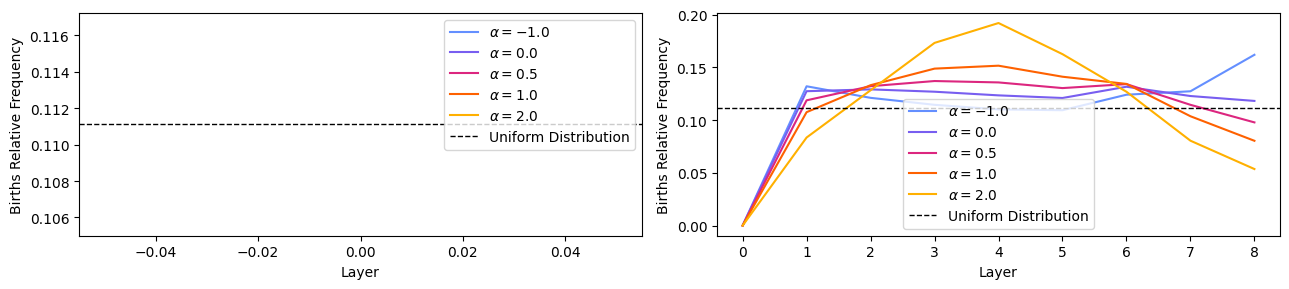

In [10]:
fig, axes = plt.subplots(1, 2, figsize = (13, 3))
for diagram, ax in zip(diagrams, axes.flat):
    zigzag.topology.plot_births_relative_frequency(diagram, num_layers, ax=ax)
fig.savefig(f"{dumper.directory_}/births_relative_frequency.png")
fig.savefig(f"{dumper.directory_}/births_relative_frequency.svg")